Walmart Store Sales - Demand Forecasting

This notebook builds an end-to-end piepline to forecast weekly dept-level sales across 45 walmart stores, using historical sales data along with some attributes, holiday timing and markdowns(promotional).

Data is from Feb 2010 to oct 2012.

**1. Setup and Data loading**

- Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

- Load train.csv, stores.csv, features.csv

In [2]:
train = pd.read_csv("/content/train.csv")

In [3]:
train

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False
421566,45,98,2012-10-05,628.10,False
421567,45,98,2012-10-12,1061.02,False
421568,45,98,2012-10-19,760.01,False


In [4]:
features = pd.read_csv("/content/features.csv")

In [5]:
features

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False


In [6]:
store = pd.read_csv("/content/stores.csv")

In [7]:
store

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [9]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [10]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


- Merge stores+features onto train

In [11]:
train["Date"] = pd.to_datetime(train["Date"])
features["Date"] = pd.to_datetime(features["Date"])

In [12]:
train_df = pd.merge(train,features,on=["Store","Date","IsHoliday"],how="left")

In [13]:
train_df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667


In [14]:
train_df = pd.merge(train_df,store,on="Store",how="left")

In [15]:
train_df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,B,118221


In [16]:
print(train_df.shape)

(421570, 16)


In [17]:
# cols descriptions
# Store - Unique identifier for each Store in Walmart (1-45)
# Dept - Dept number within a store
# Date - Week ending date for the recorded sales
# Weekly sales - target column - total weekly sales for a particular store and department
# IsHoliday - bool value showing whether the week includes a major holiday
# Temperature - Avg temp (F) for that store during the week
# fuel price - avg fuel price in the region during the week
# Markdowns 5 - means these are discounts or promotional price reductions that walmart offers to increase sales
# as I can see there are many NaN's as every week they not gonna give discounts or price reductions
# CPI - consumer price index - if prices are going up then inflation else deflation
# Unemployement - regional unemployement rate during that week
# Type - store category
# Size = Store size measured in sqft
# four major holidays are Super Bowl, Labor Day, Thanksgiving and christmas.


In [18]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

In [19]:
# ḥoliday name, in dataset from 2010-Jan to 2012-Sep
holiday_dates = {
    "2010-02-12" :"Super Bowl",
    "2011-02-11" :"Super Bowl",
    "2012-02-10":"Super Bowl",

    "2010-09-10" : "Labor Day",
    "2011-09-09" : "Labor Day",
    "2012-09-07" : "Labor Day",

    "2010-11-26" : "Thanksgiving",
    "2011-11-25" : "Thanksgiving",
    "2012-11-23" :"Thanksgiving",

    "2010-12-31" :"Christmas",
    "2011-12-30" : "Christmas",
    "2012-12-28" : "Christmas"
}

train_df["Holiday_Name"] = train_df["Date"].dt.strftime("%Y-%m-%d").map(holiday_dates).fillna("Non-holiday")


In [20]:
train_df["Holiday_Name"].value_counts()

,count
Holiday_Name,
Non-holiday,391909
Super Bowl,8895
Labor Day,8861
Thanksgiving,5959
Christmas,5946


**3. Exploratory Data Analysis**

In [21]:
train_df.describe()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000
std,12.785297,30.492054,NaN,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328


Insights
1. There are totally 45 Walmart stores and dept ids ranging from 1 to 99.However, not every store contains all dept IDs.

2. In minimum weekly sales value is negative, which mostly likely represents product returns, refunds, or sales adjustments rather than actual purchases.

3. Temp and fuel price values appear to be within reasonable ranges.

4. In markdowns also, there are some negative values, that means some promotions are negative.

In [22]:
dept_per_store = train_df.groupby("Store")["Dept"].nunique().sort_values()
dept_per_store

,Dept
Store,
43,61
44,62
37,62
42,62
33,63
36,63
38,63
30,64
5,72


Individual stores contain between 44 and 74 unique departments, indicating that dept availability varies across stores.

In [23]:
train_df.describe(include=["object","bool"])

,IsHoliday,Type,Holiday_Name
count,421570,421570,421570
unique,2,3,5
top,False,A,Non-holiday
freq,391909,215478,391909


In [24]:
train_df.duplicated().sum()
# no duplicate values

np.int64(0)

- Missing values check

In [25]:
d = {}
d["Missing_count"] = train_df.isna().sum()
d["Missing_percentage"] = round(train_df.isna().mean()*100,2)
missing_summary = pd.DataFrame(d)
missing_summary = missing_summary.sort_values(by="Missing_percentage",ascending=False)
missing_summary

,Missing_count,Missing_percentage
MarkDown2,310322,73.61
MarkDown4,286603,67.98
MarkDown3,284479,67.48
MarkDown1,270889,64.26
MarkDown5,270138,64.08
Store,0,0.00
IsHoliday,0,0.00
Dept,0,0.00
Date,0,0.00
Temperature,0,0.00


Markdowns only have the missing values, rest all are not null, as we know every week there will not be discounts or promotional offers so they are null.


### Weekly Sales Distribution

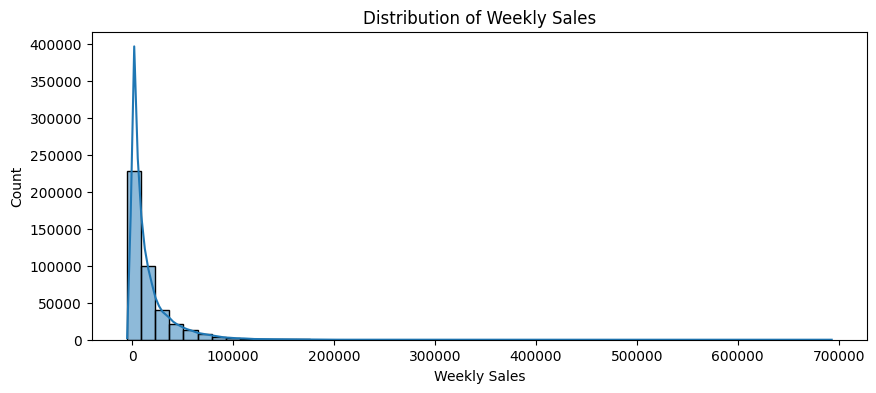

3.2620081854656657


In [26]:
plt.figure(figsize=(10,4))
sns.histplot(train_df["Weekly_Sales"], bins=50, kde=True)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Count")
plt.show()
print(train_df["Weekly_Sales"].skew())

### Zoomed version of weekly sales

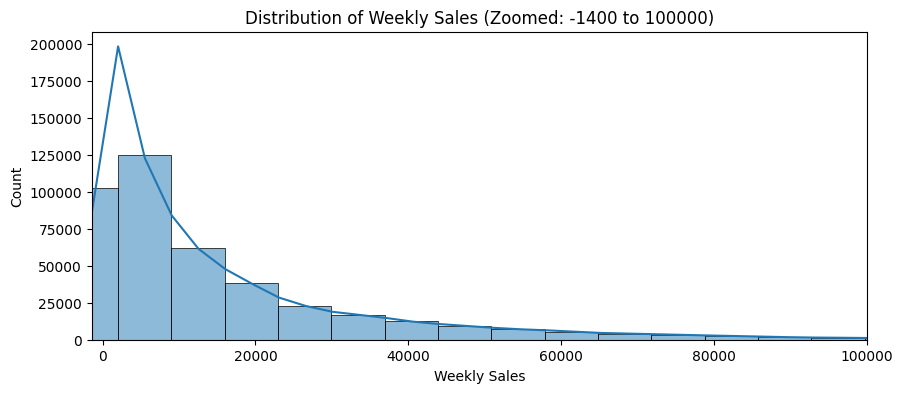

In [27]:
plt.figure(figsize=(10,4))
sns.histplot(train_df["Weekly_Sales"], bins=100, kde=True)
plt.xlim(-1400, 100000)
plt.title("Distribution of Weekly Sales (Zoomed: -1400 to 100000)")
plt.xlabel("Weekly Sales")
plt.ylabel("Count")
plt.show()

In [28]:
train_df["Weekly_Sales"].min()

-4988.94

Insights
1. The weekly_sales is unimodal ad the skewness is 3.26, it indicates the skewness is right-skewed.

2. The minimum value is (-1321) - a negative weekly sales figure.
this likely reflects weeks where product returns exceeded new purchases for that dept, ranther than a data error.


### Sales trend over time

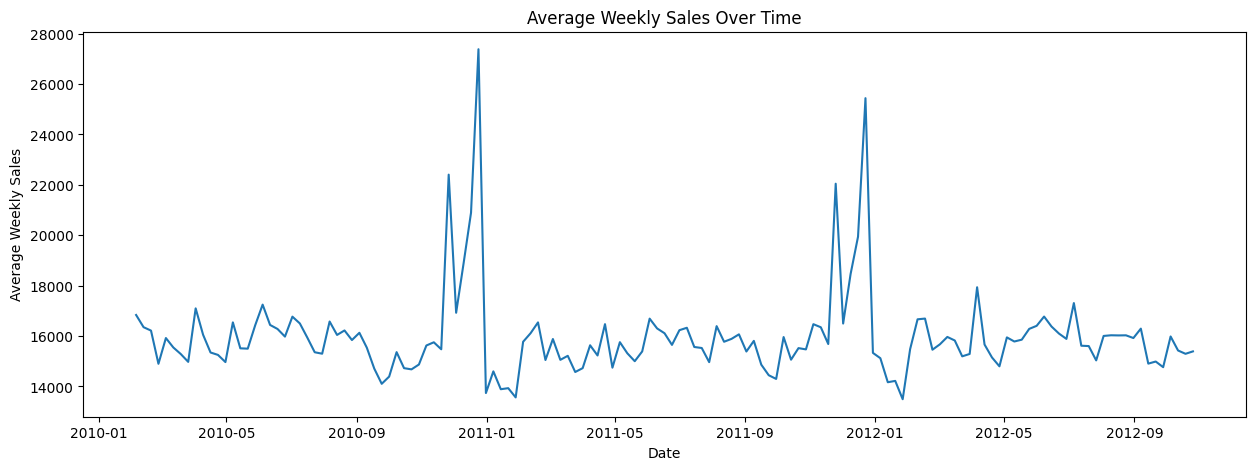

In [29]:
sales_over_time = train_df.groupby("Date")["Weekly_Sales"].mean()
# so here it gives the average sales for each store-dept row

plt.figure(figsize=(15,5))
plt.plot(sales_over_time)
plt.title("Average Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Average Weekly Sales")
plt.show()

Insight
1. Here in average weekly sales, there are sharp spikes around late november to december in both 2010 and 2011

2. After those peaks, sales drop sharply in January.

3. Because of the holidays, where Thanksgiving and Christmas weeks usually have highest sales because of holiday shopping and offers.

In [30]:
train_df.groupby("IsHoliday")["Weekly_Sales"].agg(["mean", "median", "sum", "std"])

,mean,median,sum,std
IsHoliday,,,,
False,15901.445069,7589.95,6.231919e+09,22330.747450
True,17035.823187,7947.74,5.052996e+08,27222.000409


as I can see here, the mean for True that means for holidays only there is more sales. but the sum is more for non-holiday weeks, because there is an imbalance in holiday vs non-holiday

### Average Sales: Holiday vs Non-Holiday

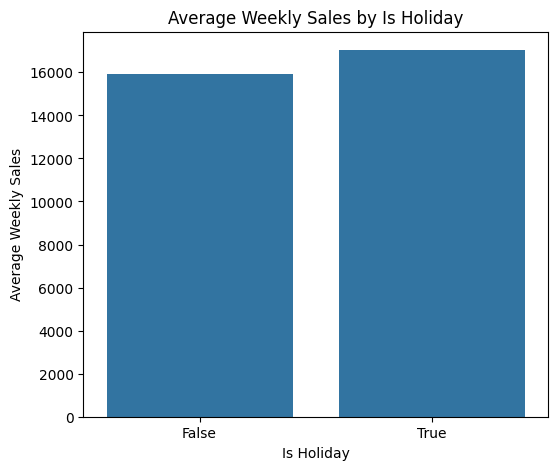

In [31]:
holiday_mean = (train_df.groupby("IsHoliday")["Weekly_Sales"].mean().reset_index())

plt.figure(figsize=(6,5))
sns.barplot(data=holiday_mean,x="IsHoliday",y="Weekly_Sales")
plt.title("Average Weekly Sales by Is Holiday")
plt.xlabel("Is Holiday")
plt.ylabel("Average Weekly Sales")
plt.show()

Insight
1. Based on the plot, the average sales for holidays is more than non_holidays.

### Sales by Store Type

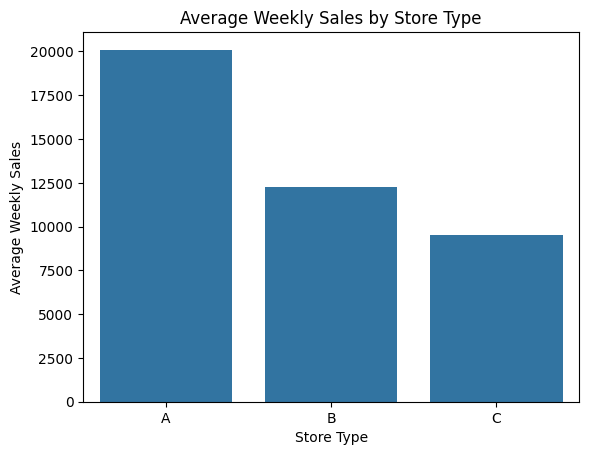

In [32]:
type_avg_sales = train_df.groupby("Type")["Weekly_Sales"].mean().reset_index()
sns.barplot(x="Type", y="Weekly_Sales", data=type_avg_sales)
plt.title("Average Weekly Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Weekly Sales")
plt.show()

1. As we can see the type A store is having more avg weekly sales than other 2 types of stores, as we know the size of store A is more,

In [33]:
train_df[["Type","Size"]]

,Type,Size
0,A,151315
1,A,151315
2,A,151315
3,A,151315
4,A,151315
...,...,...
421565,B,118221
421566,B,118221
421567,B,118221
421568,B,118221


In [34]:
train_df["Size"].nunique()

40

In [35]:
train_df[train_df['Store'] == 1][['Store', 'Dept', 'Date', 'Type', 'Size']].head(10)

,Store,Dept,Date,Type,Size
0,1,1,2010-02-05,A,151315
1,1,1,2010-02-12,A,151315
2,1,1,2010-02-19,A,151315
3,1,1,2010-02-26,A,151315
4,1,1,2010-03-05,A,151315
5,1,1,2010-03-12,A,151315
6,1,1,2010-03-19,A,151315
7,1,1,2010-03-26,A,151315
8,1,1,2010-04-02,A,151315
9,1,1,2010-04-09,A,151315


### Average Sales vs Store Size

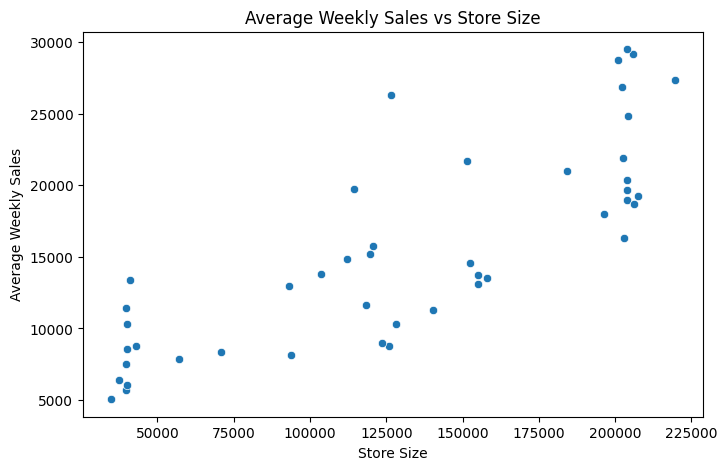

In [36]:
store_avg = train_df.groupby("Store").agg({"Weekly_Sales": "mean","Size": "first"}).reset_index()

plt.figure(figsize=(8,5))
sns.scatterplot(data=store_avg, x="Size", y="Weekly_Sales")
plt.title("Average Weekly Sales vs Store Size")
plt.xlabel("Store Size")
plt.ylabel("Average Weekly Sales")
plt.show()

Insights
1. Store size shows a clear positive relationship with average weekly sales like larger stores (Type A) generally sell more than smaller ones like C, similar to the prev plot.

2. Store size is a strong factor but incomplete driver of sales.

3. As if we look at the right side of the plot (like bigger stores with 150000+), the points are not climbing steadily, they spread out vertically instead.

4. So size doesnt fully explain sales, especially for the bigger stores, something else must be driving the differences I see betweem 2 similarily sized sotres.

Takeaway for modeling
Dont rely on size/type alone as the only strong features. feature engineering is also required

### Top and bottom 10 departments by sales

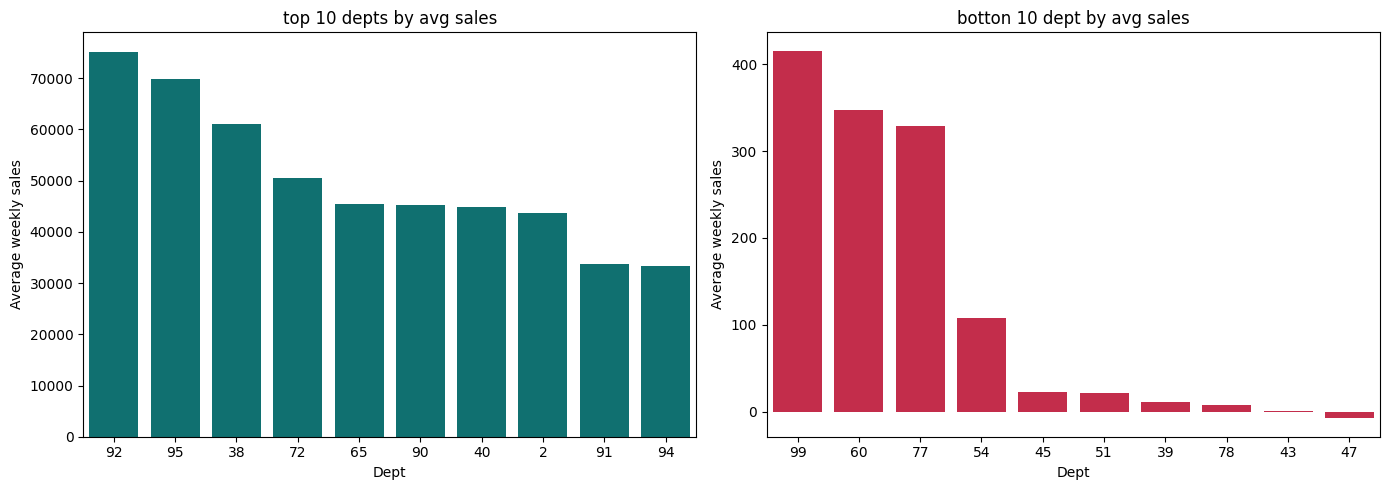

In [37]:
dept_wise_avg = train_df.groupby("Dept")["Weekly_Sales"].mean().sort_values(ascending=False)
top_10 = dept_wise_avg.head(10)
bottom_10 = dept_wise_avg.tail(10)

fig,axes = plt.subplots(1,2,figsize=(14,5))
sns.barplot(data=top_10,color="teal",ax=axes[0],order=top_10.index)
axes[0].set_title("top 10 depts by avg sales")
axes[0].set_ylabel("Average weekly sales")

sns.barplot(data=bottom_10,color="crimson",ax=axes[1],order=bottom_10.index)
axes[1].set_title("botton 10 dept by avg sales")
axes[1].set_ylabel("Average weekly sales")
plt.tight_layout()
plt.show()

Insights
1. Departments 92,95 and 38 lead with average weekly sales between 60000 and 75000.

2. Bottom performers are departments 47,43 and 78 avg under 20 in weekly sales.

3. The best depat 92 sells roughly 150-200 times more per week than the worst.

In [38]:
holiday_sales = train_df.groupby("Holiday_Name")["Weekly_Sales"].mean().sort_values(ascending=False)
holiday_sales

,Weekly_Sales
Holiday_Name,
Thanksgiving,22220.944538
Super Bowl,16377.996441
Non-holiday,15901.445069
Labor Day,15881.693339
Christmas,14543.387158


### Sales by holidays

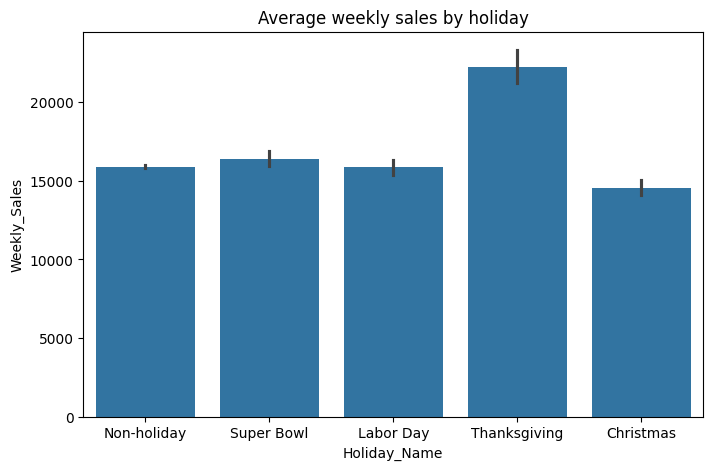

In [39]:
plt.figure(figsize=(8,5))
sns.barplot(data=train_df,x="Holiday_Name",y="Weekly_Sales",estimator=np.mean)
# plt.xticks(rotation=20)
plt.title("Average weekly sales by holiday")
plt.show()

### Missing values visualization

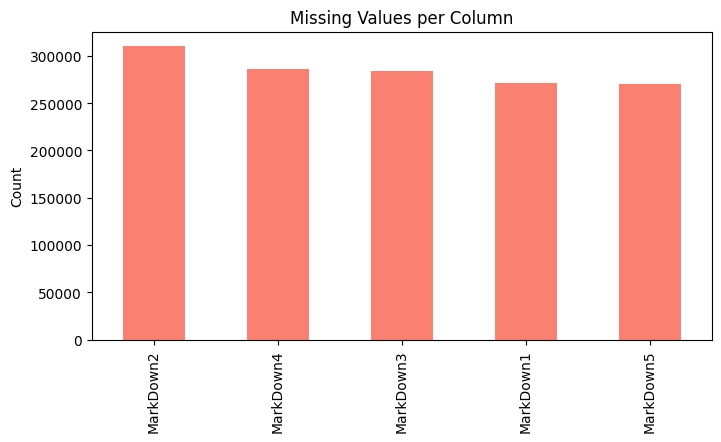

In [40]:
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8,4))
missing.plot(kind='bar', color='salmon')
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.show()

### correaltion heatmap

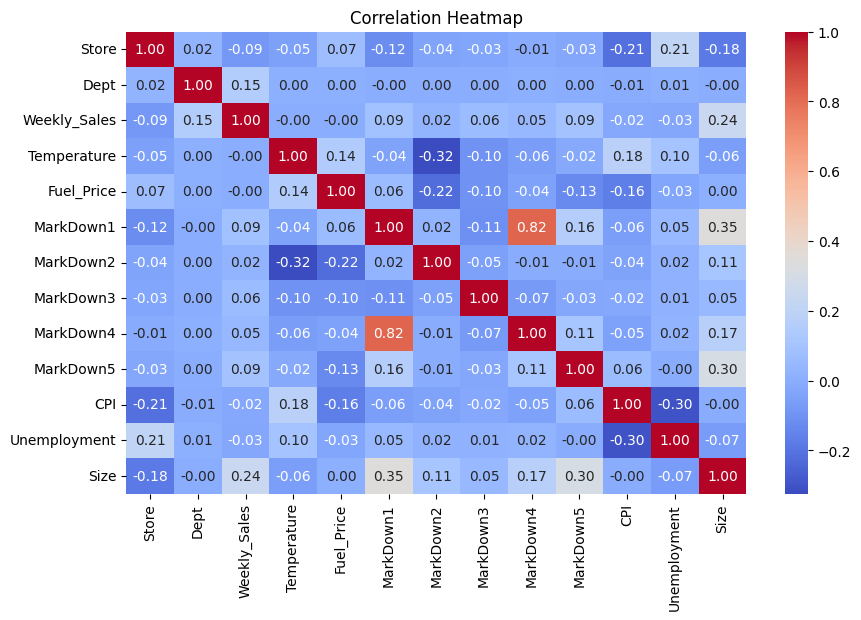

In [41]:
plt.figure(figsize=(10,6))
numeric_cols = train_df.select_dtypes(include=np.number)
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

1. Weekly sales (Target) barely correlates with any single feature.

2. This means sales aren't driven by simple linear relationships like no single number (temp,fuel,cpi) predicts sales well on its own.

3. MarkDown1 and 4 are highly correlated, they carry mostly the same info. somewhat redundant.

4. CPI and unemployement are negatively correlated, regions with higher unemployement tend to have lower cpi.

5. Since correlations are weak, sales are likely driven by categorical/non linear patterns (store, dept or holiday timing) rather than smooth numeric trends.

In [42]:
missing_summary

,Missing_count,Missing_percentage
MarkDown2,310322,73.61
MarkDown4,286603,67.98
MarkDown3,284479,67.48
MarkDown1,270889,64.26
MarkDown5,270138,64.08
Store,0,0.00
IsHoliday,0,0.00
Dept,0,0.00
Date,0,0.00
Temperature,0,0.00


Missing values indicator
1. As missing values are only in markdown from 1 to 5.

2. As it is mentioned in the info, that markdown is only available after nov 2011

3. So before nov 2011, markdown informaiton simply wasn't collected or provided.

4. After nov 2011, not every store had markdown data every week.

5. missing % is about 64 to 74% so dropping them is not an option.

6. Mean/median imputation would assign artificial promotion values where none are known.

7. So fill them with 0's and flag them for the models to understand better.

**4. Data cleaning**
- Markdown fillna(0) + markdown flag

In [43]:
# creating a missing indicator for all 5 markdowns
markdown_cols = ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]
for i in markdown_cols:
  train_df[f"{i}_missing"] = train_df[i].isna().astype(int)
  train_df[i] = train_df[i].fillna(0)

In [44]:
train_df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'Holiday_Name',
       'MarkDown1_missing', 'MarkDown2_missing', 'MarkDown3_missing',
       'MarkDown4_missing', 'MarkDown5_missing'],
      dtype='object')

In [45]:
train_df.isna().mean()

,0
Store,0.0
Dept,0.0
Date,0.0
Weekly_Sales,0.0
IsHoliday,0.0
Temperature,0.0
Fuel_Price,0.0
MarkDown1,0.0
MarkDown2,0.0
MarkDown3,0.0


In [46]:
train_df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,CPI,Unemployment,Type,Size,Holiday_Name,MarkDown1_missing,MarkDown2_missing,MarkDown3_missing,MarkDown4_missing,MarkDown5_missing
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.00,0.00,0.00,...,211.096358,8.106,A,151315,Non-holiday,1,1,1,1,1
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.00,0.00,0.00,...,211.242170,8.106,A,151315,Super Bowl,1,1,1,1,1
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.00,0.00,0.00,...,211.289143,8.106,A,151315,Non-holiday,1,1,1,1,1
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.00,0.00,0.00,...,211.319643,8.106,A,151315,Non-holiday,1,1,1,1,1
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.00,0.00,0.00,...,211.350143,8.106,A,151315,Non-holiday,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,...,192.013558,8.684,B,118221,Non-holiday,0,0,0,0,0
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,0.00,18.82,...,192.170412,8.667,B,118221,Non-holiday,0,1,0,0,0
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,0.00,7.89,...,192.327265,8.667,B,118221,Non-holiday,0,1,0,0,0
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,0.00,3.18,...,192.330854,8.667,B,118221,Non-holiday,0,1,0,0,0


In [47]:
# Before Nov 2011
train_df[train_df["Date"] < "2011-11-01"][["Date","MarkDown1"]].head(10)

,Date,MarkDown1
0,2010-02-05,0.0
1,2010-02-12,0.0
2,2010-02-19,0.0
3,2010-02-26,0.0
4,2010-03-05,0.0
5,2010-03-12,0.0
6,2010-03-19,0.0
7,2010-03-26,0.0
8,2010-04-02,0.0
9,2010-04-09,0.0


In [48]:
# After Nov 2011
train_df[train_df["Date"] >= "2011-11-01"][["Date","MarkDown1"]].head(10)

,Date,MarkDown1
91,2011-11-04,0.00
92,2011-11-11,10382.90
93,2011-11-18,6074.12
94,2011-11-25,410.31
95,2011-12-02,5629.51
96,2011-12-09,4640.65
97,2011-12-16,5011.32
98,2011-12-23,2725.36
99,2011-12-30,5762.10
100,2012-01-06,6277.39


In [49]:
train_df[["Date"]].head(20)

,Date
0,2010-02-05
1,2010-02-12
2,2010-02-19
3,2010-02-26
4,2010-03-05
5,2010-03-12
6,2010-03-19
7,2010-03-26
8,2010-04-02
9,2010-04-09


- Outliers flagging(IQR, not removed)

In [50]:
# Outlier check - using IQR on log-transformed sales, per Store-Dept group
# (log-transformed because raw sales vary by orders of magnitude across departments)
train_df['log_sales'] = np.log1p(train_df['Weekly_Sales'] - train_df['Weekly_Sales'].min() + 1)

def flag_outliers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (group < lower) | (group > upper)

train_df['is_outlier'] = train_df.groupby(['Store', 'Dept'])['log_sales'].transform(flag_outliers)

train_df['is_outlier'].value_counts()
train_df['is_outlier'].mean() * 100

np.float64(3.555755864980905)

weekly sales contains negative values, as I already mentioned due to returns or adjustments.

So sales are first shifted to +ve values before applying log transformation

the log transformation reduces skewness

In [51]:
train_df[train_df['is_outlier']]['IsHoliday'].mean() * 100

np.float64(17.37158105403602)

so outliers % is 3.56%, which is approx 15000rows

out of these flagged outlier rows, 17.4% are holiday weeks % in outliers

### Basic feature engineering - extracted calendar based features from the date column

- These features help capture yearly, monthly, weekly and seasonal sales patterns

In [52]:
train_df["Year"] = train_df["Date"].dt.year
train_df["Month"] = train_df["Date"].dt.month
train_df["Week"] = train_df["Date"].dt.isocalendar().week
train_df["Quarter"] = train_df["Date"].dt.quarter
train_df["DayOfYear"] = train_df["Date"].dt.dayofyear

In [53]:
# sort data according to time
train_df = train_df.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

In [54]:
# Evaluation function
# computes all evaluation metrics req for this project:
# MAE, RMSE, WMAE (kaggle competition metric), MAPE, R2
def evaluate_model(y_true,y_pred,is_holiday,model_name="Model"):
  mae = mean_absolute_error(y_true,y_pred)
  rmse = np.sqrt(mean_squared_error(y_true,y_pred))

  # wmae - holidays weeks weighted 5x
  # np.where(condition,value_if_true,value_if_false)
  # true means give weight as 5 and false means weight as 1
  weights = np.where(is_holiday,5,1)

  wmae = np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

  # mape - means percentages
  # mape - only compute on rows where actual sales are meaningfully non-zero
  mask = np.abs(y_true) > 100
  mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
  r2 = r2_score(y_true,y_pred)

  return {"model":model_name, "MAE":mae,"RMSE":rmse,"WMAE":wmae,"MAPE":mape,"R2":r2}



In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

# as i cant do train_test_split
split_date = train_df["Date"].quantile(0.85)
train = train_df[train_df["Date"] < split_date]
val = train_df[train_df["Date"] >= split_date]

X_train = train.drop(columns=["Weekly_Sales","Date","log_sales","is_outlier"])
y_train = train["Weekly_Sales"]

X_val = val.drop(columns=["Weekly_Sales","Date","log_sales","is_outlier"])
y_val = val["Weekly_Sales"]

ohe_feature = ["Type","Holiday_Name"]

ohe_pipeline = OneHotEncoder(handle_unknown="ignore",drop="if_binary",sparse_output=False)

preprocessor = ColumnTransformer(
    transformers = [
        ('ohe_block',ohe_pipeline,ohe_feature)
    ],
    remainder="passthrough"
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",LinearRegression())
])

pipeline.fit(X_train,y_train)
pred = pipeline.predict(X_val)

results_baseline = evaluate_model(y_val,pred,val["IsHoliday"],model_name = "Linear Regression (baseline)")
results_baseline


{'model': 'Linear Regression (baseline)',
 'MAE': 14616.114425212758,
 'RMSE': np.float64(20967.664068806804),
 'WMAE': np.float64(14672.085116484033),
 'MAPE': np.float64(699.7145549075719),
 'R2': 0.09384365147821594}

1. The baseline linear regression model performs poorly, with an R2 of only 0.094, meaning it only explains 9.4% of the variation in weekly sales.

2. The MAE of 14616.11 indicates that, on avg, predictions differ from the actual weekly sales by more than 14000 units/dollars, which is too high for an accurate demand forecasting.

3. RMSE (20968) is larger than mae, that menas model makes some very large prediction errors.

4. MAPE (699.7%) that % errors are very large, because the baseline model is not capturing seasonality, holiday effects, or sales history.

5. The small gap between MAE and WMAE suggests that the baseline model does not treat holiday weeks very differently from regular weeks. However, there is still room for improvement in capturing holiday demand patterns.

In [56]:
train_df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'Holiday_Name',
       'MarkDown1_missing', 'MarkDown2_missing', 'MarkDown3_missing',
       'MarkDown4_missing', 'MarkDown5_missing', 'log_sales', 'is_outlier',
       'Year', 'Month', 'Week', 'Quarter', 'DayOfYear'],
      dtype='object')

In [57]:
# feature engineering

# do it based on stores and dept, not the dataset wise

# days to holiday

In [58]:
holiday_dates = pd.to_datetime([
    "2010-02-12",
    "2011-02-11",
    "2012-02-10",

    "2010-09-10",
    "2011-09-09",
    "2012-09-07",

    "2010-11-26",
    "2011-11-25",
    "2012-11-23",

    "2010-12-31",
    "2011-12-30",
    "2012-12-28"
])

train_df["Days_to_Holiday"] = train_df["Date"].apply(lambda date: np.min(np.abs((holiday_dates - date).days)))



In [59]:
train_df[["Date","Holiday_Name","Days_to_Holiday"]].head(50)

,Date,Holiday_Name,Days_to_Holiday
0,2010-02-05,Non-holiday,7
1,2010-02-12,Super Bowl,0
2,2010-02-19,Non-holiday,7
3,2010-02-26,Non-holiday,14
4,2010-03-05,Non-holiday,21
5,2010-03-12,Non-holiday,28
6,2010-03-19,Non-holiday,35
7,2010-03-26,Non-holiday,42
8,2010-04-02,Non-holiday,49
9,2010-04-09,Non-holiday,56


In [60]:
# check that within each group, Date is increasing
is_sorted_within_group = train_df.groupby(['Store', 'Dept'])['Date'].apply(
    lambda x: x.is_monotonic_increasing
)
is_sorted_within_group.value_counts()


,count
Date,
True,3331


### More feature engineering for next models

In [61]:
# first make sure data is sorted - lag features depend on row order within each group
train_df = train_df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

# Lag features - sales from previous weeks, per Store-Dept
train_df['Sales_lag_1'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
train_df['Sales_lag_4'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(4)
train_df['Sales_lag_52'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52)

# check the NaNs each lag introduced
train_df[['Sales_lag_1', 'Sales_lag_4', 'Sales_lag_52']].isnull().sum()

,0
Sales_lag_1,3331
Sales_lag_4,13134
Sales_lag_52,160487


1. lag features allow the model to learn temporal dependencies by using historical sales information.

2. A 1-week lag captures short-term demand patterns

3. A 4-week lag captures monthly purchasing behavior.

4. A 52 week captures yearly seasonality, it helps the model learn recussing sales patterns such as holiday demand.

In [62]:
group = train_df.groupby(["Store","Dept"])["Weekly_Sales"]
# avg sales over the prev 4 weeks
train_df["Sales_roll_mean_4"] = group.transform(lambda x: x.shift(1).rolling(4).mean())
# standard deviation of sales over the prev 4 weeks
train_df["Sales_roll_std_4"] = group.transform(lambda x: x.shift(1).rolling(4).std())

so rolling std is small for store A then it is very stable.

if for ex for store B rolling std is large very unstable

rolling mean captures the recent sales trend by averaging the prev four weeks sales.

rolling std captures the recent variability or volatility in sales.

so these 2 features help the model understand whether sales have been consistently high, consistently low or fluctuating.

Measures how much sales varied over the previous four weeks.

A small rolling standard deviation means sales have been relatively stable.

A large rolling standard deviation means sales have fluctuated significantly, indicating volatile demand.

#### Markdown*holiday - to model the combined effect of promotions during major holiday periods

In [63]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
train_df['Total_markdown'] = train_df[markdown_cols].sum(axis=1)
train_df['Markdown_x_holiday'] = train_df['Total_markdown'] * train_df['IsHoliday'].astype(int)

promotions often have a stronger impact during majot holidays because customer customer behavior changes.

By multiplying the total markdown by the holiday indicator, I created an interaction feature that allows the model to learn whether promotions are more effective during holiday weeks than during regular weeks.

In [64]:
train_df = train_df.dropna(subset=['Sales_lag_52']).reset_index(drop=True)

# final check - should be 0 across all engineered columns
train_df[['Sales_lag_1','Sales_lag_4','Sales_lag_52','Sales_roll_mean_4','Sales_roll_std_4']].isnull().sum()

,0
Sales_lag_1,0
Sales_lag_4,0
Sales_lag_52,0
Sales_roll_mean_4,0
Sales_roll_std_4,0


In [65]:
# time-based train-val split
split_date = train_df["Date"].quantile(0.85)
train = train_df[train_df["Date"] < split_date]
val = train_df[train_df["Date"] >= split_date]
X_train = train.drop(columns=["Weekly_Sales", "Date", "log_sales", "is_outlier"])
y_train = train["Weekly_Sales"]
X_val = val.drop(columns=["Weekly_Sales", "Date", "log_sales", "is_outlier"])
y_val = val["Weekly_Sales"]

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf = 5,
        random_state=42,
        n_jobs=-1,
        verbose=1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=1
    )
}

In [67]:
from tqdm import tqdm
results = []
for model_name, model in tqdm(models.items(), desc="Training models"):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    pred_train = pipeline.predict(X_train)
    pred_val = pipeline.predict(X_val)
    train_metrics = evaluate_model(y_train, pred_train, train["IsHoliday"], model_name)
    val_metrics = evaluate_model(y_val, pred_val, val["IsHoliday"], model_name)

    results.append({
        "Model": model_name,
        "Train MAE": train_metrics["MAE"], "Validation MAE": val_metrics["MAE"],
        "Train RMSE": train_metrics["RMSE"], "Validation RMSE": val_metrics["RMSE"],
        "Train WMAE": train_metrics["WMAE"], "Validation WMAE": val_metrics["WMAE"],
        "Train MAPE": train_metrics["MAPE"], "Validation MAPE": val_metrics["MAPE"],
        "Train R2": train_metrics["R2"], "Validation R2": val_metrics["R2"]
    })

results_df = pd.DataFrame(results)
display(results_df.round(3))

Training models:  33%|███▎      | 1/3 [00:03<00:07,  3.60s/it][Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  6.9min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    2.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.5s finished
Training models: 100%|██████████| 3/3 [07:33<00:00, 151.09s/it]


,Model,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train WMAE,Validation WMAE,Train MAPE,Validation MAPE,Train R2,Validation R2
0,Linear Regression,1672.387,1558.881,3709.816,2943.168,1800.551,1606.646,28.492,37.538,0.974,0.982
1,Random Forest,1046.089,1214.999,2279.664,2552.978,1085.186,1251.307,12.611,14.069,0.990,0.986
2,XGBoost,954.777,1239.832,1646.155,2655.579,964.315,1275.661,14.256,15.599,0.995,0.985


Feature engineering improved the performance of all three models compared to the baseline model

Random forest achieved best validation performace among the initial models with the lowest val WMAE 1251 and val MAE 1215

XGboost performed similar to random forest, but showed slightly higher validation error


### Hyperpamater tuning

In [68]:
! pip install optuna

In [69]:
import optuna

In [70]:
X_train_ready = preprocessor.fit_transform(X_train)
X_val_ready = preprocessor.transform(X_val)

In [71]:
# import optuna

# def xgb_objective(trial):
#     params = {
#         "n_estimators": trial.suggest_int("n_estimators", 100, 500),
#         "max_depth": trial.suggest_int("max_depth", 3, 10),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
#         "subsample": trial.suggest_float("subsample", 0.6, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
#         "random_state": 42,
#         "n_jobs": -1,
#         "early_stopping_rounds": 20,   # stops training a bad trial early - big time saver
#     }

#     model = XGBRegressor(**params)
#     model.fit(
#         X_train_ready, y_train,
#         eval_set=[(X_val_ready, y_val)],
#         verbose=False
#     )

#     pred = model.predict(X_val_ready)

#     metrics = evaluate_model(y_val, pred, val["IsHoliday"], model_name="XGB")
#     return metrics["WMAE"]   # minimize WMAE - the actual competition metric


# study_xgb = optuna.create_study(direction="minimize",sampler=optuna.samplers.TPESampler(seed=42))
# study_xgb.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

# print("Best WMAE:", study_xgb.best_value)
# print("Best params:", study_xgb.best_params)

In [72]:
# Best parameters obtained from Optuna
best_params = {
    "n_estimators": 458,
    "max_depth": 9,
    "learning_rate": 0.03033489137308524,
    "subsample": 0.9422407411684662,
    "colsample_bytree": 0.7118966902204166,
    "min_child_weight": 2,
    "reg_alpha": 1.802605809913643,
    "reg_lambda": 7.658802266594283
}

pipeline_xgb_optuna = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        **best_params,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_xgb_optuna.fit(X_train, y_train)

pred_train = pipeline_xgb_optuna.predict(X_train)
pred_val = pipeline_xgb_optuna.predict(X_val)

train_metrics = evaluate_model(y_train,pred_train,train["IsHoliday"],model_name="XGBoost (Optuna)")

val_metrics = evaluate_model(y_val,pred_val,val["IsHoliday"],model_name="XGBoost (Optuna)")

results.append({
    "Model": "XGBoost (Optuna)",

    "Train MAE": train_metrics["MAE"],
    "Validation MAE": val_metrics["MAE"],

    "Train RMSE": train_metrics["RMSE"],
    "Validation RMSE": val_metrics["RMSE"],

    "Train WMAE": train_metrics["WMAE"],
    "Validation WMAE": val_metrics["WMAE"],

    "Train MAPE": train_metrics["MAPE"],
    "Validation MAPE": val_metrics["MAPE"],

    "Train R2": train_metrics["R2"],
    "Validation R2": val_metrics["R2"]
})

results_df = pd.DataFrame(results)

display(results_df.round(3))

,Model,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train WMAE,Validation WMAE,Train MAPE,Validation MAPE,Train R2,Validation R2
0,Linear Regression,1672.387,1558.881,3709.816,2943.168,1800.551,1606.646,28.492,37.538,0.974,0.982
1,Random Forest,1046.089,1214.999,2279.664,2552.978,1085.186,1251.307,12.611,14.069,0.990,0.986
2,XGBoost,954.777,1239.832,1646.155,2655.579,964.315,1275.661,14.256,15.599,0.995,0.985
3,XGBoost (Optuna),1045.297,1209.714,1940.723,2536.662,1053.777,1250.612,14.352,14.919,0.993,0.987


1. Hyperpameter tuning improves xgboosts validation performace, reducing the val WMAE from 1275 to 1250 and increasing the Validation R2 from 0.985 to 0.987



In [73]:
cv_df = train_df.sort_values("Date").reset_index(drop=True)

In [74]:
from sklearn.model_selection import TimeSeriesSplit


# Final tuned XGBoost model
best_params = {
    "n_estimators": 458,
    "max_depth": 9,
    "learning_rate": 0.03033489137308524,
    "subsample": 0.9422407411684662,
    "colsample_bytree": 0.7118966902204166,
    "min_child_weight": 2,
    "reg_alpha": 1.802605809913643,
    "reg_lambda": 7.658802266594283
}

# Time Series Split
tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(cv_df), start=1):

    train_fold = train_df.iloc[train_idx]
    val_fold = train_df.iloc[val_idx]

    X_train_fold = train_fold.drop(columns=["Weekly_Sales", "Date", "log_sales", "is_outlier"])
    y_train_fold = train_fold["Weekly_Sales"]

    X_val_fold = val_fold.drop(columns=["Weekly_Sales", "Date", "log_sales", "is_outlier"])
    y_val_fold = val_fold["Weekly_Sales"]

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(**best_params,random_state=42,n_jobs=-1))])

    pipeline.fit(X_train_fold, y_train_fold)
    pred = pipeline.predict(X_val_fold)
    metrics = evaluate_model(y_val_fold,pred,val_fold["IsHoliday"],model_name=f"Fold {fold}")
    cv_results.append(metrics)

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df.round(3))

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,model,MAE,RMSE,WMAE,MAPE,R2
0,Fold 1,1819.423,4607.376,1951.749,16.876,0.970
1,Fold 2,1496.048,3278.608,1595.135,16.664,0.977
2,Fold 3,1533.122,3247.504,1612.902,15.277,0.978
3,Fold 4,1097.831,2743.006,1188.630,23.204,0.978
4,Fold 5,1121.653,2529.831,1166.074,15.838,0.984


1. Fold 1 has the highest error because it was trained on the samllest amount of historical data.

2. As the training window expanded on later folds, both mae and wmae decreases, showing that additional historical data improved forecasting performance.

3. R2 score consistently high across all folds indicated that model generalizes well over different time periods and is suitable for demand forecasting.

### Residual vs predicted

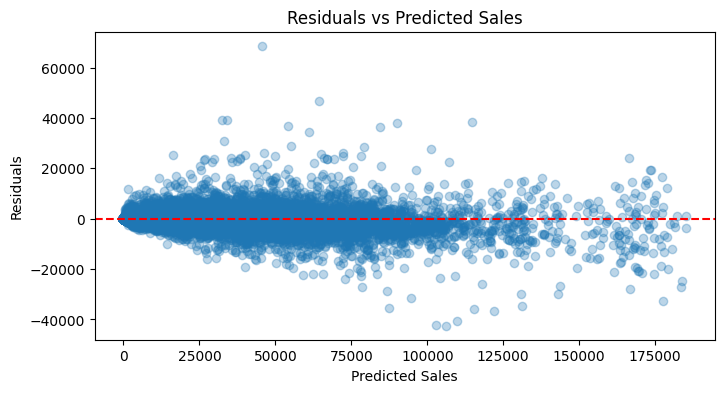

In [75]:
xgb_pred = pipeline_xgb_optuna.predict(X_val)
residuals = y_val - xgb_pred

plt.figure(figsize=(8,4))
plt.scatter(xgb_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Sales")
plt.show()

Residuals are distributed around the zero line, indicating that the model does not show a consistemt bias towards over or under prediction.

a few large residuals are present, likely corresponding to exceptional events such as holidays or unsually high sales periods.

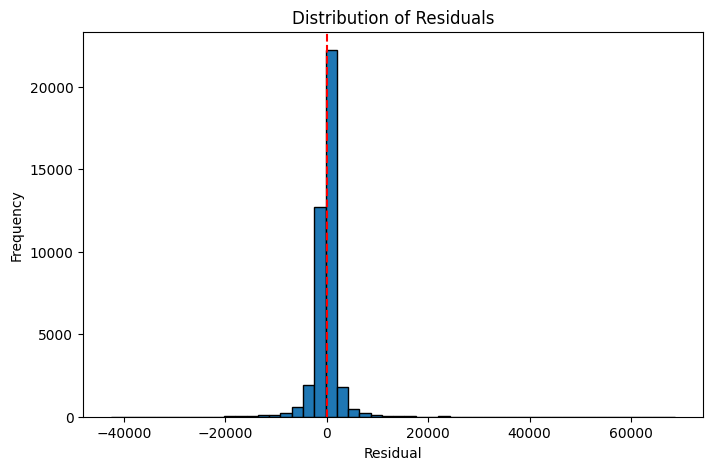

In [76]:
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=50, edgecolor="black")
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

### Robustness testing

In [77]:
xgb_pred = pipeline_xgb_optuna.predict(X_val)

val_results = val.copy()
val_results["Prediction"] = xgb_pred

# Holiday weeks
holiday = val_results[val_results["IsHoliday"]]
holiday_metrics = evaluate_model(holiday["Weekly_Sales"],holiday["Prediction"],holiday["IsHoliday"],model_name="Holiday")

# Non-holiday weeks
non_holiday = val_results[~val_results["IsHoliday"]]
nonholiday_metrics = evaluate_model(non_holiday["Weekly_Sales"],non_holiday["Prediction"],
                                    non_holiday["IsHoliday"],model_name="Non-Holiday")

pd.DataFrame([holiday_metrics, nonholiday_metrics]).round(3)

,model,MAE,RMSE,WMAE,MAPE,R2
0,Holiday,1393.815,3021.134,1393.815,17.527,0.983
1,Non-Holiday,1195.559,2495.522,1195.559,14.719,0.987


Holiday vs Non-Holiday weeks

The model performs slightly better during non-holiday weeks.

Because holiday sales are more volatile and difficult to predict.



In [78]:
store_results = []

for store_type in sorted(val_results["Type"].unique()):
    subset = val_results[val_results["Type"] == store_type]

    metrics = evaluate_model(
        subset["Weekly_Sales"],subset["Prediction"],
        subset["IsHoliday"],model_name=f"Store Type {store_type}")

    store_results.append(metrics)

pd.DataFrame(store_results).round(3)

,model,MAE,RMSE,WMAE,MAPE,R2
0,Store Type A,1458.318,2920.030,1501.442,13.717,0.987
1,Store Type B,1056.486,2211.745,1096.429,16.293,0.980
2,Store Type C,541.856,1340.122,573.600,15.980,0.993


Evaluated performance across Store Types A,B,C

The model generalized well across all store types.

Store type C achieved the lowest prediction error, while Store Type A showed slightly higher errors due to large sales variability.



In [79]:
val_results["Markdown_Level"] = pd.qcut(
    val_results["Total_markdown"],
    q=3,
    labels=["Low", "Medium", "High"]
)

markdown_results = []

for level in ["Low", "Medium", "High"]:
    subset = val_results[val_results["Markdown_Level"] == level]

    metrics = evaluate_model(subset["Weekly_Sales"],subset["Prediction"],subset["IsHoliday"],model_name=level)

    markdown_results.append(metrics)

pd.DataFrame(markdown_results).round(3)

,model,MAE,RMSE,WMAE,MAPE,R2
0,Low,811.552,1788.707,794.480,16.191,0.987
1,Medium,1284.704,2564.280,1324.412,14.270,0.987
2,High,1534.271,3089.229,1576.007,14.395,0.985


Sales records are grouped into low, medium and high markdown categories.

The model remained accurate across all promotional levels.

Prediction errors increased slightly for high markdown periods, indicating that large promotions introduce additional uncertainty in customer demand.

Overall the tuned XGBoost model demonstrated stable performance across different holiday periods, store types and promotion levels, indicating good generalization and robustness for real-world retail sales forecasting.


SHAP

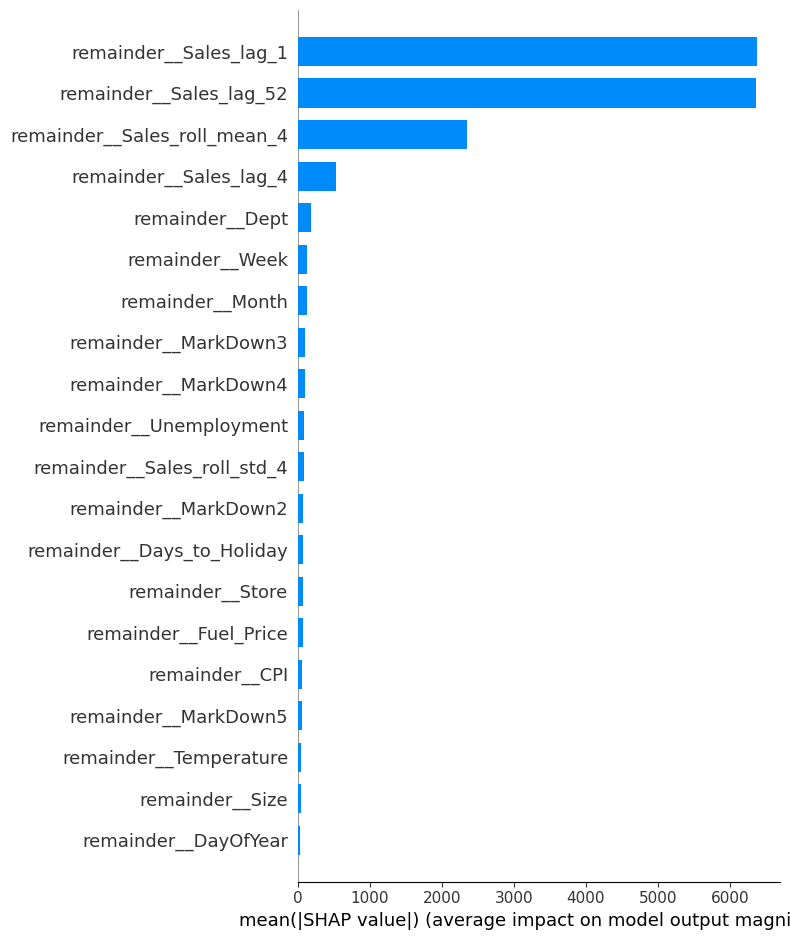

In [80]:
import shap
import pandas as pd
import numpy as np

xgb_model = pipeline_xgb_optuna.named_steps["model"]
X_val_transformed = pipeline_xgb_optuna.named_steps["preprocessor"].transform(X_val)
feature_names = pipeline_xgb_optuna.named_steps["preprocessor"].get_feature_names_out()

sample_idx = np.random.RandomState(42).choice(len(X_val_transformed), size=min(3000, len(X_val_transformed)), replace=False)
X_val_sample = X_val_transformed[sample_idx]
X_val_df = pd.DataFrame(X_val_sample, columns=feature_names)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val_sample)

shap.summary_plot(shap_values, X_val_df, feature_names=feature_names, plot_type="bar")


Highest Error Prediction (row 11425)
Actual: 114230.60 | Predicted: 45542.95 | Error: 68687.65


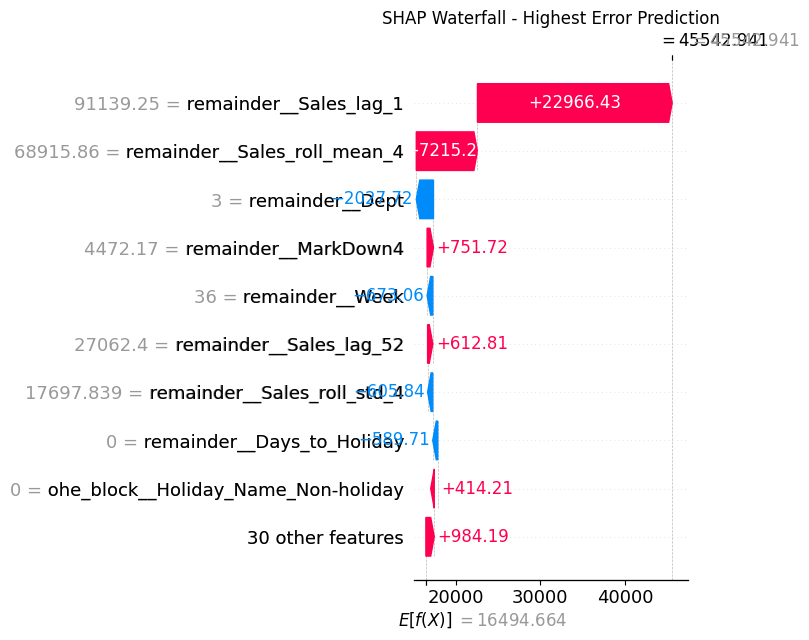


Lowest Error Prediction (row 33138)
Actual: 154.06 | Predicted: 154.06 | Error: 0.00


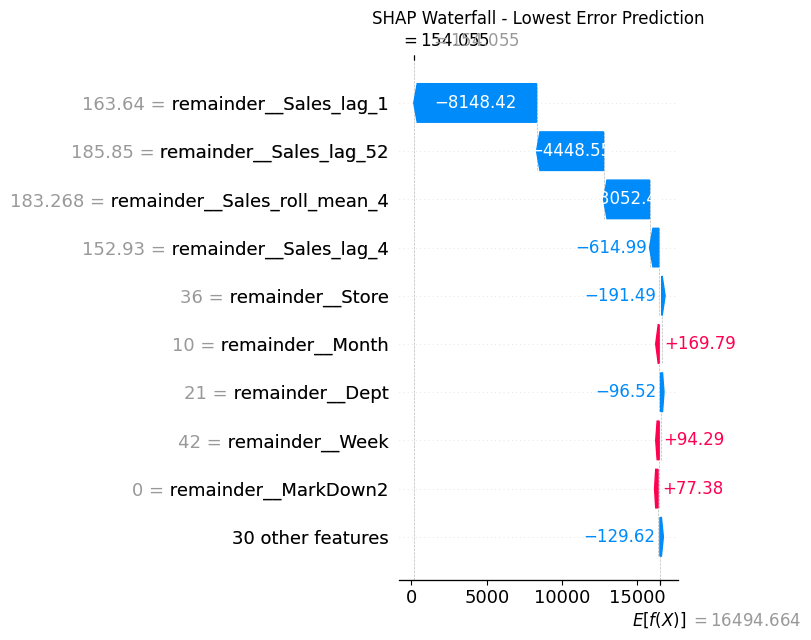


Random Prediction (row 15795)
Actual: 6390.18 | Predicted: 6182.06 | Error: 208.12


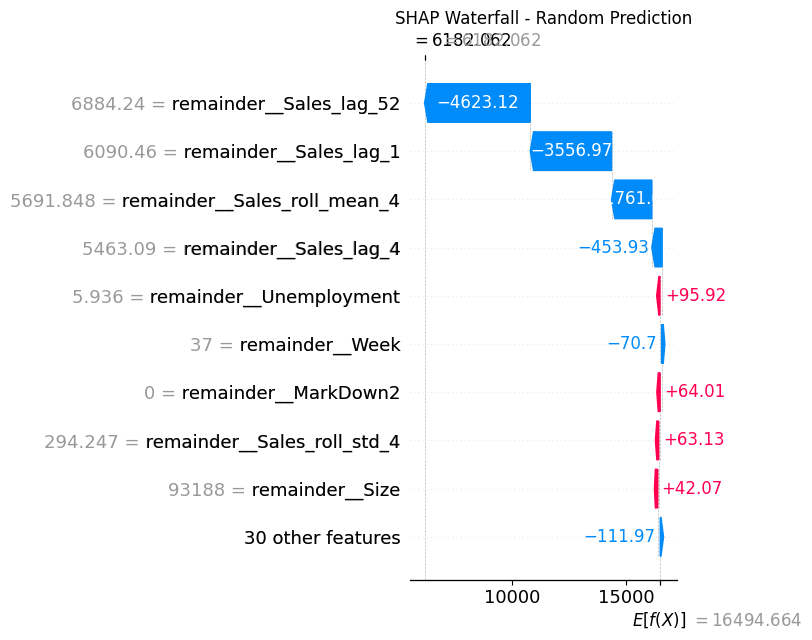

In [89]:
y_val_pred_full = xgb_model.predict(X_val_transformed)
errors_full = np.abs(y_val.values - y_val_pred_full)

idx_high_error = errors_full.argmax()
idx_low_error = errors_full.argmin()
idx_random = np.random.RandomState(42).choice(len(errors_full))

example_indices = {
    "Highest Error Prediction": idx_high_error,
    "Lowest Error Prediction": idx_low_error,
    "Random Prediction": idx_random
}

X_local = X_val_transformed[list(example_indices.values())]
shap_values_local = explainer.shap_values(X_local)

explanation_local = shap.Explanation(
    values=shap_values_local,
    base_values=explainer.expected_value,
    data=X_local,
    feature_names=feature_names
)

for i, (label, idx) in enumerate(example_indices.items()):
    print(f"\n{label} (row {idx})")
    print(f"Actual: {y_val.values[idx]:.2f} | Predicted: {y_val_pred_full[idx]:.2f} | Error: {errors_full[idx]:.2f}")
    plt.figure()
    shap.plots.waterfall(explanation_local[i], show=False)
    plt.title(f"SHAP Waterfall - {label}")
    plt.tight_layout()
    plt.show()

Highest error, the model massively under-predicted here.

This is very likely a holiday spikr or an unusual promotionsl event that the log/rolling features couldn't fully anticipate.

lets check this row Highest Error Prediction (row 11425)

In [84]:
val.iloc[idx_high_error][["Store", "Dept", "Date", "IsHoliday", "Type", "Size",
                           "Total_markdown", "Sales_lag_1", "Sales_lag_52",
                           "Sales_roll_mean_4"]]

,73440
Store,13
Dept,3
Date,2012-09-07 00:00:00
IsHoliday,True
Type,A
Size,219622
Total_markdown,27193.07
Sales_lag_1,91139.25
Sales_lag_52,27062.4
Sales_roll_mean_4,68915.86


The model's largest error happened on a holiday week with a big markdown, where it under predicted sales by ~68,700, it leaned too heavily on last year's lower sales for that week and didn't fully capture the extra lift from the holiday promotion combination.

In [90]:
!pip freeze > requirements.txt